In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
%pip install numpy pandas matplotlib seaborn torch optuna scikit-learn statsmodels scipy seaborn

In [3]:
import os

config = {
    # ============================================================
    # 데이터 / 예측 길이
    # ============================================================
    "input_len": 400,
    "model_output_len": 100,   # 학습 시 한 번에 예측하는 길이
    "eval_output_len": 200,    # test AR 최종 예측 길이: 100-step × 2회
    "metric_output_len": 200,
    "stride": 100,

    # 현재 상태 변수와 최종 보고 변수
    "state_cols": ["heave", "surge"],
    "target_cols": ["heave", "surge"],
    "report_col": "heave",

    "downsample_factor": 1,

    # ============================================================
    # PCA
    # X에만 적용하며 y에는 적용하지 않음
    # 누적 설명 분산이 95% 이상이 될 때까지 주성분을 선택
    # ============================================================
    "use_pca": True,
    "pca_n_components": 0.95,

    # ============================================================
    # 실험 이름 / 모델
    # ============================================================
    "experiment_name": "lstm_transformer_db",
    "model_names": ["LSTM", "Transformer"],

    # 모델 공통 기본값
    "hidden_size": 16,
    "num_layers": 2,

    # Transformer
    "nhead": 2,
    "dim_feedforward": 64,
    "dropout": 0.0,

    # 최종 학습
    "lr": 0.001,
    "epoch": 10000,
    "batch_size": 64,
    "grad_clip": 1.0,
    "patience": 10,

    # TCN
    "tcn_channels": [32, 32, 64],
    "tcn_kernel_size": 3,
    "tcn_dropout": 0.1,

    # ============================================================
    # Loss
    # mse, ep, dilate, tildeq, db, kmbdf, cp
    # ============================================================
    "loss_type": "db",
    "peak_percentile": 90,
    "t_peak": None,

    # 전체 2변수 loss에 추가할 heave 보조 MSE 가중치
    "heave_loss_weight": 1.0,

    # MSE + EP loss
    "lambda_peak": 0.05,
    "fu": 1.4,
    "fo": 1.4,

    # TILDE-Q-like loss
    "lambda_tildeq": 0.02,
    "lambda_amp": 0.05,
    "lambda_fft_phase": 0.01,
    "lambda_corr": 0.10,

    # Checkpoint
    "save_checkpoints": True,
    "checkpoint_root": "./loss_checkpoints",

    # Optuna
    "use_optuna_best_params": True,
    "run_optuna": True,
    "optuna_n_trials": 30,
    "optuna_epoch": 30,
    "optuna_patience": 5,

    # 결과 저장
    "results_dir": "./results_ar_eval_200",
}

# 파생 설정
config["target_dim"] = len(config["target_cols"])
config["heave_idx"] = config["target_cols"].index(config["report_col"])

assert config["eval_output_len"] == 200
assert config["eval_output_len"] % config["model_output_len"] == 0
assert set(config["target_cols"]).issubset(set(config["state_cols"]))

config["experiment_dir"] = os.path.join(
    config["results_dir"], config["experiment_name"]
)
config["optuna_best_params_path"] = os.path.join(
    config["experiment_dir"], "optuna_best_params_by_model.json"
)
config["checkpoint_dir"] = os.path.join(
    config["checkpoint_root"], config["experiment_name"]
)

os.makedirs(config["experiment_dir"], exist_ok=True)
os.makedirs(config["checkpoint_dir"], exist_ok=True)

print("입력 길이:", config["input_len"])
print("학습 출력 길이:", config["model_output_len"])
print("Test AR 출력 길이:", config["eval_output_len"])
print("AR 반복 횟수:", config["eval_output_len"] // config["model_output_len"])
print("상태 변수:", config["state_cols"])
print("학습 target:", config["target_cols"])
print("최종 평가 변수:", config["report_col"])
print("PCA 사용:", config["use_pca"], "| n_components:", config["pca_n_components"])
print("실험 경로:", config["experiment_dir"])


입력 길이: 400
학습 출력 길이: 100
Test AR 출력 길이: 200
AR 반복 횟수: 2
상태 변수: ['heave', 'surge']
학습 target: ['heave', 'surge']
최종 평가 변수: heave
PCA 사용: True | n_components: 0.95
실험 경로: ./results_ar_eval_200\lstm_transformer_db


#1. 데이터 저장

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch
import torch.nn as nn
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from torch.utils.data import DataLoader, TensorDataset, Dataset

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

data_path = Path(config.get("data_path", "merged_data.csv"))
if not data_path.exists() and (Path.cwd().parent / data_path).exists():
    data_path = Path.cwd().parent / data_path
if not data_path.exists():
    raise FileNotFoundError(f"데이터 파일을 찾을 수 없습니다: {data_path.resolve()}")

clean_columns = ["time", "surge", "sway", "heave", "roll", "pitch", "yaw", "source_file"]

df = pd.read_csv(
    data_path, 
    encoding="utf-8-sig", 
    header=0,        
    names=clean_columns  
)

numeric_cols = ["time", "surge", "sway", "heave", "roll", "pitch", "yaw"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

rows_before = len(df)

# 유효하지 않은 데이터 제거
df = df.dropna(subset=numeric_cols + ["source_file"]).copy()
df["source_file"] = df["source_file"].astype(str).str.strip()
df = df[df["source_file"] != ""].reset_index(drop=True)

print("데이터 경로:", data_path.resolve())
print(f"유효하지 않은 행 제거: {rows_before - len(df):,}")
print("shape:", df.shape, "| source_file 수:", df["source_file"].nunique())
print(df.dtypes)
display(df.head())

데이터 경로: C:\Users\user\Desktop\minkyung\lab\merged_data.csv
유효하지 않은 행 제거: 0
shape: (3200000, 8) | source_file 수: 64
time           float64
surge          float64
sway           float64
heave          float64
roll           float64
pitch          float64
yaw            float64
source_file     object
dtype: object


,time,surge,sway,heave,roll,pitch,yaw,source_file
0,0.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,090_Tm_11.5_HS_3.5
1,0.2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,090_Tm_11.5_HS_3.5
2,0.3,4.373029e-09,5.355001e-08,4.919359e-08,-8.497136e-10,4.371078e-09,-1.673461e-08,090_Tm_11.5_HS_3.5
3,0.4,2.267250e-08,2.812216e-07,2.690394e-07,-9.670982e-10,2.188110e-08,-8.257464e-08,090_Tm_11.5_HS_3.5
4,0.5,6.985890e-08,8.779171e-07,8.653567e-07,6.655777e-09,6.487034e-08,-2.433273e-07,090_Tm_11.5_HS_3.5


샘플링 정보 기준 source_file: 090_Tm_11.5_HS_3.5
샘플 수: 50,000
총 길이: 4999.90 s
샘플링 간격 dt (median): 0.1000 s
샘플링 주파수 fs: 10.0000 Hz
dt 불균일 구간 수: 0


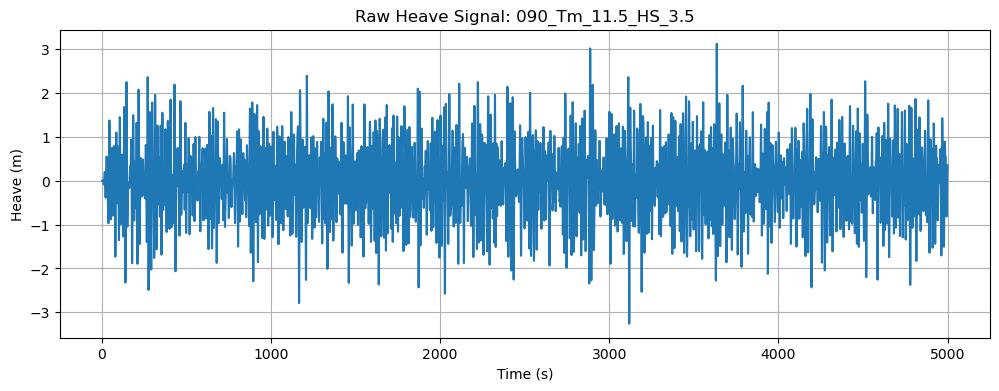

In [5]:
import numpy as np

# source_file마다 시간이 0 부근에서 다시 시작하므로, 샘플링 정보는 파일 내부에서 계산합니다.
first_source_file = df["source_file"].iloc[0]
first_signal = (
    df.loc[df["source_file"] == first_source_file]
    .sort_values("time")
    .reset_index(drop=True)
)
time = first_signal["time"].to_numpy(dtype=float)
heave = first_signal["heave"].to_numpy(dtype=float)
time_diffs = np.diff(time)
positive_diffs = time_diffs[time_diffs > 0]

if len(positive_diffs) == 0:
    raise ValueError(f"{first_source_file}에서 양수 시간 간격을 찾지 못했습니다.")

dt = float(np.median(positive_diffs))
fs = 1.0 / dt
non_uniform_count = int(np.count_nonzero(~np.isclose(positive_diffs, dt)))

print("샘플링 정보 기준 source_file:", first_source_file)
print(f"샘플 수: {len(heave):,}")
print(f"총 길이: {time[-1] - time[0]:.2f} s")
print(f"샘플링 간격 dt (median): {dt:.4f} s")
print(f"샘플링 주파수 fs: {fs:.4f} Hz")
print(f"dt 불균일 구간 수: {non_uniform_count:,}")

plt.figure(figsize=(12, 4))
plt.plot(time, heave)
plt.xlabel("Time (s)")
plt.ylabel("Heave (m)")
plt.title(f"Raw Heave Signal: {first_source_file}")
plt.grid(True)
plt.show()


In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ── 시드 고정 ─────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ============================================================
# 1. 변수 설정
# ============================================================
base_input_cols = list(config["state_cols"])
target_cols = list(config["target_cols"])
report_col = config["report_col"]

INPUT_LEN = int(config["input_len"])
MODEL_OUTPUT_LEN = int(config["model_output_len"])
EVAL_OUTPUT_LEN = int(config["eval_output_len"])
CURRENT_STRIDE = int(config["stride"])
METRIC_OUTPUT_LEN = int(config.get("metric_output_len", EVAL_OUTPUT_LEN))

assert set(target_cols).issubset(set(base_input_cols)), (
    "자유 AR에서는 target_cols가 state/input 변수에 포함되어야 합니다."
)
assert report_col in target_cols
assert EVAL_OUTPUT_LEN >= MODEL_OUTPUT_LEN
assert EVAL_OUTPUT_LEN % MODEL_OUTPUT_LEN == 0
assert METRIC_OUTPUT_LEN <= EVAL_OUTPUT_LEN

config["target_dim"] = len(target_cols)
config["heave_idx"] = target_cols.index(report_col)

print("base_input_cols:", base_input_cols)
print("target_cols:", target_cols)
print("report_col:", report_col)
print(
    "MODEL_OUTPUT_LEN:", MODEL_OUTPUT_LEN,
    "| EVAL_OUTPUT_LEN:", EVAL_OUTPUT_LEN,
    "| METRIC_OUTPUT_LEN:", METRIC_OUTPUT_LEN,
)

# ============================================================
# 2. source_file 기준 Train / Val / Test split
# ============================================================
df_sorted = df.sort_values(["source_file", "time"]).reset_index(drop=True)
source_files = sorted(df_sorted["source_file"].unique())

n_files = len(source_files)
if n_files < 3:
    raise ValueError("source_file이 최소 3개 이상 필요합니다.")

train_end = max(1, int(n_files * 0.70))
val_end = max(train_end + 1, int(n_files * 0.85))
val_end = min(val_end, n_files - 1)

train_files = source_files[:train_end]
val_files = source_files[train_end:val_end]
test_files = source_files[val_end:]

train_data = df_sorted[df_sorted["source_file"].isin(train_files)].copy()
val_data = df_sorted[df_sorted["source_file"].isin(val_files)].copy()
test_data = df_sorted[df_sorted["source_file"].isin(test_files)].copy()

print("=" * 70)
print("Train / Val / Test split")
print("train files:", len(train_files), "| rows:", len(train_data))
print("val files:", len(val_files), "| rows:", len(val_data))
print("test files:", len(test_files), "| rows:", len(test_data))

# ============================================================
# 3. 다운샘플링
# ============================================================
def downsample_df(df_in, factor, source_col="source_file", time_col="time"):
    if factor is None or factor <= 1:
        return df_in.copy()

    parts = []
    for _, group in df_in.groupby(source_col):
        group = group.sort_values(time_col).reset_index(drop=True)
        parts.append(group.iloc[::factor].reset_index(drop=True))
    return pd.concat(parts, ignore_index=True)

DOWNSAMPLE_FACTOR = int(config.get("downsample_factor", 1))
train_data = downsample_df(train_data, DOWNSAMPLE_FACTOR)
val_data = downsample_df(val_data, DOWNSAMPLE_FACTOR)
test_data = downsample_df(test_data, DOWNSAMPLE_FACTOR)

print("downsample_factor:", DOWNSAMPLE_FACTOR)
print("downsampled rows:", len(train_data), len(val_data), len(test_data))

train_proc = train_data.copy()
val_proc = val_data.copy()
test_proc = test_data.copy()
input_cols = base_input_cols.copy()
pre_pca_input_cols = input_cols.copy()
print("pre_pca_input_cols:", pre_pca_input_cols)

# ============================================================
# 5. 변수별 scaler를 연속 train 데이터에 fit
# - 각 변수는 독립적으로 [-1, 1] scaling
# ============================================================
feature_scalers = {}

for col in pre_pca_input_cols:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train_proc[[col]].astype(float).values)
    feature_scalers[col] = scaler


def scale_dataframe(df_in, cols, scalers):
    df_out = df_in.copy()
    for col in cols:
        if col not in scalers:
            raise KeyError(f"scaler가 없는 변수입니다: {col}")
        df_out[col] = scalers[col].transform(
            df_out[[col]].astype(float).values
        ).reshape(-1)
    return df_out


def inverse_scale_feature(values_scaled, col):
    values = np.asarray(values_scaled)
    shape = values.shape
    restored = feature_scalers[col].inverse_transform(values.reshape(-1, 1))
    return restored.reshape(shape)


def inverse_scale_targets(values_scaled):
    """(..., target_dim)의 scaled target을 원래 단위로 복원."""
    values = np.asarray(values_scaled)
    if values.shape[-1] != len(target_cols):
        raise ValueError(
            f"마지막 차원은 target_dim={len(target_cols)}이어야 합니다: {values.shape}"
        )

    restored = np.empty_like(values, dtype=np.float64)
    for idx, col in enumerate(target_cols):
        restored[..., idx] = inverse_scale_feature(values[..., idx], col)
    return restored


train_scaled = scale_dataframe(train_proc, pre_pca_input_cols, feature_scalers)
val_scaled = scale_dataframe(val_proc, pre_pca_input_cols, feature_scalers)
test_scaled = scale_dataframe(test_proc, pre_pca_input_cols, feature_scalers)

print("=" * 70)
print("Variable-wise scaler ranges fitted on continuous train data")
for col in pre_pca_input_cols:
    scaler = feature_scalers[col]
    print(
        f"{col:>12s}: train min={scaler.data_min_[0]: .6f}, "
        f"train max={scaler.data_max_[0]: .6f}"
    )

# ============================================================
# 6. PCA: scaled continuous train X에만 fit
#    y(target_cols)에는 PCA를 적용하지 않음
# ============================================================
pca_model = None
use_pca = bool(config.get("use_pca", False))

if use_pca:
    requested_components = config.get("pca_n_components", 0.95)
    if isinstance(requested_components, int):
        requested_components = min(requested_components, len(pre_pca_input_cols))

    pca_model = PCA(n_components=requested_components)
    pca_model.fit(train_scaled[pre_pca_input_cols].values)

    model_input_cols = [
        f"pca_{i + 1}" for i in range(pca_model.n_components_)
    ]

    def add_pca_columns(df_scaled):
        df_out = df_scaled.copy()
        z = pca_model.transform(df_out[pre_pca_input_cols].values)
        for i, col in enumerate(model_input_cols):
            df_out[col] = z[:, i]
        return df_out

    train_model_df = add_pca_columns(train_scaled)
    val_model_df = add_pca_columns(val_scaled)
    test_model_df = add_pca_columns(test_scaled)

    print("=" * 70)
    print("PCA components:", pca_model.n_components_)
    print("Explained variance ratio:", pca_model.explained_variance_ratio_)
    print("Explained variance sum:", float(pca_model.explained_variance_ratio_.sum()))
else:
    model_input_cols = pre_pca_input_cols.copy()
    train_model_df = train_scaled
    val_model_df = val_scaled
    test_model_df = test_scaled

config["input_dim"] = len(model_input_cols)
config["target_dim"] = len(target_cols)


def model_to_pre_pca_scaled(x_model):
    """모델 입력 공간(PCA 또는 scaled feature)을 pre-PCA scaled 공간으로 변환."""
    x = np.asarray(x_model)
    shape = x.shape
    if shape[-1] != len(model_input_cols):
        raise ValueError(f"model input dim 불일치: {shape}")

    if not use_pca:
        return x.copy()

    restored = pca_model.inverse_transform(x.reshape(-1, shape[-1]))
    return restored.reshape(*shape[:-1], len(pre_pca_input_cols))


def pre_pca_to_model_scaled(x_pre):
    """pre-PCA scaled feature를 모델 입력 공간으로 변환."""
    x = np.asarray(x_pre)
    shape = x.shape
    if shape[-1] != len(pre_pca_input_cols):
        raise ValueError(f"pre-PCA input dim 불일치: {shape}")

    if not use_pca:
        return x.copy()

    transformed = pca_model.transform(x.reshape(-1, shape[-1]))
    return transformed.reshape(*shape[:-1], len(model_input_cols))

# ============================================================
# 7. Sliding window 생성
#    Train/Val: 미래 100-step × 2변수
#    Test: 미래 200-step × 2변수
# ============================================================
def create_sequences_multivariate(
    data_df,
    input_cols,
    target_cols,
    input_len=400,
    output_len=100,
    stride=100,
):
    data_df = data_df.sort_values("time").reset_index(drop=True)

    x_values = data_df[input_cols].astype(float).values
    y_values = data_df[target_cols].astype(float).values

    x_list, y_list = [], []
    last_start = len(data_df) - input_len - output_len

    for start in range(0, last_start + 1, stride):
        input_end = start + input_len
        output_end = input_end + output_len
        x_list.append(x_values[start:input_end])
        y_list.append(y_values[input_end:output_end])

    if not x_list:
        return (
            np.empty((0, input_len, len(input_cols)), dtype=np.float32),
            np.empty((0, output_len, len(target_cols)), dtype=np.float32),
        )

    return np.asarray(x_list), np.asarray(y_list)


def create_sequences_multivariate_by_file(
    data_df,
    input_cols,
    target_cols,
    input_len,
    output_len,
    stride,
):
    x_all, y_all = [], []

    for source_file, file_df in data_df.groupby("source_file"):
        x, y = create_sequences_multivariate(
            file_df,
            input_cols=input_cols,
            target_cols=target_cols,
            input_len=input_len,
            output_len=output_len,
            stride=stride,
        )
        if len(x) == 0:
            print(f"sequence 생략: {source_file} (길이 부족)")
            continue
        x_all.append(x)
        y_all.append(y)

    if not x_all:
        raise ValueError(
            "생성된 sequence가 없습니다. input_len/output_len/stride 또는 파일 길이를 확인하세요."
        )

    return np.vstack(x_all), np.vstack(y_all)


X_t, y_t = create_sequences_multivariate_by_file(
    train_model_df,
    input_cols=model_input_cols,
    target_cols=target_cols,
    input_len=INPUT_LEN,
    output_len=MODEL_OUTPUT_LEN,
    stride=CURRENT_STRIDE,
)
X_v, y_v = create_sequences_multivariate_by_file(
    val_model_df,
    input_cols=model_input_cols,
    target_cols=target_cols,
    input_len=INPUT_LEN,
    output_len=MODEL_OUTPUT_LEN,
    stride=CURRENT_STRIDE,
)
X_test, y_test = create_sequences_multivariate_by_file(
    test_model_df,
    input_cols=model_input_cols,
    target_cols=target_cols,
    input_len=INPUT_LEN,
    output_len=EVAL_OUTPUT_LEN,
    stride=CURRENT_STRIDE,
)

heave_idx = target_cols.index(report_col)
config["heave_idx"] = heave_idx
config["t_peak"] = float(
    np.percentile(
        np.abs(y_t[..., heave_idx].reshape(-1)),
        config.get("peak_percentile", 90),
    )
)

print("=" * 70)
print("Final tensors")
print("model_input_cols:", model_input_cols)
print("pre_pca_input_cols:", pre_pca_input_cols)
print("target_cols:", target_cols)
print("X_t:", X_t.shape, "| y_t:", y_t.shape)
print("X_v:", X_v.shape, "| y_v:", y_v.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)
print("t_peak (scaled heave):", config["t_peak"])

assert X_t.shape[1:] == (INPUT_LEN, config["input_dim"])
assert y_t.shape[1:] == (MODEL_OUTPUT_LEN, config["target_dim"])
assert y_test.shape[1:] == (EVAL_OUTPUT_LEN, config["target_dim"])

# 전처리 객체 저장
os.makedirs(config["experiment_dir"], exist_ok=True)
preprocessing_path = os.path.join(config["experiment_dir"], "preprocessing.joblib")
joblib.dump(
    {
        "feature_scalers": feature_scalers,
        "pca_model": pca_model,
        "base_input_cols": base_input_cols,
        "pre_pca_input_cols": pre_pca_input_cols,
        "model_input_cols": model_input_cols,
        "target_cols": target_cols,
        "report_col": report_col,
    },
    preprocessing_path,
)
print("preprocessing 저장:", preprocessing_path)

# ============================================================
# 8. Dataset / DataLoader
# ============================================================
class MotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = MotionDataset(X_t, y_t)
val_dataset = MotionDataset(X_v, y_v)
test_dataset = MotionDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
)

print("=" * 70)
print("Train Dataset:", train_dataset.X.shape, train_dataset.y.shape)
print("Val Dataset:", val_dataset.X.shape, val_dataset.y.shape)
print("Test Dataset:", test_dataset.X.shape, test_dataset.y.shape)
print("=" * 70)


device: cpu
base_input_cols: ['heave', 'surge']
target_cols: ['heave', 'surge']
report_col: heave
MODEL_OUTPUT_LEN: 100 | EVAL_OUTPUT_LEN: 200 | METRIC_OUTPUT_LEN: 200
Train / Val / Test split
train files: 44 | rows: 2200000
val files: 10 | rows: 500000
test files: 10 | rows: 500000
downsample_factor: 1
downsampled rows: 2200000 500000 500000
pre_pca_input_cols: ['heave', 'surge']
Variable-wise scaler ranges fitted on continuous train data
       heave: train min=-9.026668, train max= 9.679226
       surge: train min=-2.713621, train max= 2.426227
PCA components: 2
Explained variance ratio: [0.75248415 0.24751585]
Explained variance sum: 1.0
Final tensors
model_input_cols: ['pca_1', 'pca_2']
pre_pca_input_cols: ['heave', 'surge']
target_cols: ['heave', 'surge']
X_t: (21824, 400, 2) | y_t: (21824, 100, 2)
X_v: (4960, 400, 2) | y_v: (4960, 100, 2)
X_test: (4950, 400, 2) | y_test: (4950, 200, 2)
t_peak (scaled heave): 0.2847026183298163
preprocessing 저장: ./results_ar_eval_200\lstm_transfo

#2. 모델 및 학습

In [ ]:
import math
import torch
import torch.nn as nn


def reshape_forecast(raw_output, batch_size, output_len, target_dim):
    return raw_output.view(batch_size, output_len, target_dim)


class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_len, target_dim):
        super().__init__()
        self.output_len = output_len
        self.target_dim = target_dim
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
        )
        self.fc = nn.Linear(hidden_size, output_len * target_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        raw = self.fc(out[:, -1, :])
        return reshape_forecast(raw, x.size(0), self.output_len, self.target_dim)


class LSTM(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_len,
        target_dim,
        dropout=0.0,
    ):
        super().__init__()
        recurrent_dropout = dropout if num_layers > 1 else 0.0
        self.output_len = output_len
        self.target_dim = target_dim
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=recurrent_dropout,
        )
        self.fc = nn.Linear(hidden_size, output_len * target_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        raw = self.fc(out[:, -1, :])
        return reshape_forecast(raw, x.size(0), self.output_len, self.target_dim)


class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_len, target_dim):
        super().__init__()
        self.output_len = output_len
        self.target_dim = target_dim
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_len * target_dim)

    def forward(self, x):
        out, _ = self.gru(x)
        raw = self.fc(out[:, -1, :])
        return reshape_forecast(raw, x.size(0), self.output_len, self.target_dim)


class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_len, target_dim):
        super().__init__()
        self.output_len = output_len
        self.target_dim = target_dim
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_size * 2, output_len * target_dim)

    def forward(self, x):
        out, _ = self.bilstm(x)
        raw = self.fc(out[:, -1, :])
        return reshape_forecast(raw, x.size(0), self.output_len, self.target_dim)


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.0):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation,
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation,
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else None
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.dropout1(self.relu1(self.chomp1(self.conv1(x))))
        out = self.dropout2(self.relu2(self.chomp2(self.conv2(out))))
        residual = x if self.downsample is None else self.downsample(x)
        return self.relu(out + residual)


class TCN(nn.Module):
    def __init__(
        self,
        input_size,
        output_len,
        target_dim,
        channels=(32, 32, 64),
        kernel_size=3,
        dropout=0.1,
    ):
        super().__init__()
        self.output_len = output_len
        self.target_dim = target_dim
        layers = []
        in_channels = input_size
        for i, out_channels in enumerate(channels):
            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    dilation=2 ** i,
                    dropout=dropout,
                )
            )
            in_channels = out_channels
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], output_len * target_dim)

    def forward(self, x):
        out = self.network(x.transpose(1, 2))
        raw = self.fc(out[:, :, -1])
        return reshape_forecast(raw, x.size(0), self.output_len, self.target_dim)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_len,
        target_dim,
        nhead=2,
        dim_feedforward=64,
        dropout=0.0,
    ):
        super().__init__()
        if hidden_size % nhead != 0:
            raise ValueError("hidden_size must be divisible by nhead")

        self.output_len = output_len
        self.target_dim = target_dim
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="relu",
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )
        self.fc = nn.Linear(hidden_size, output_len * target_dim)

    def forward(self, x):
        z = self.pos_encoder(self.input_proj(x))
        out = self.transformer(z)
        raw = self.fc(out[:, -1, :])
        return reshape_forecast(raw, x.size(0), self.output_len, self.target_dim)


In [ ]:
def build_model(config):
    model_name = config.get("model_name", "LSTM")
    common = {
        "input_size": config["input_dim"],
        "output_len": config["model_output_len"],
        "target_dim": config["target_dim"],
    }

    if model_name == "RNN":
        return RNN(
            **common,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
        )

    if model_name == "LSTM":
        return LSTM(
            **common,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config.get("dropout", 0.0),
        )

    if model_name == "GRU":
        return GRU(
            **common,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
        )

    if model_name == "BiLSTM":
        return BiLSTM(
            **common,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
        )

    if model_name == "TCN":
        return TCN(
            **common,
            channels=config.get("tcn_channels", [32, 32, 64]),
            kernel_size=config.get("tcn_kernel_size", 3),
            dropout=config.get("tcn_dropout", 0.1),
        )

    if model_name == "Transformer":
        return TransformerModel(
            **common,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            nhead=config["nhead"],
            dim_feedforward=config["dim_feedforward"],
            dropout=config["dropout"],
        )

    raise ValueError(f"Unknown model_name: {model_name}")


In [ ]:
import copy
import json
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


def get_experiment_dir(config):
    experiment_dir = config.get("experiment_dir")
    if experiment_dir is None:
        experiment_name = config.get("experiment_name", "default_experiment")
        experiment_dir = os.path.join(
            config.get("results_dir", "./results_ar_eval_200"),
            experiment_name,
        )
    os.makedirs(experiment_dir, exist_ok=True)
    return experiment_dir


def get_checkpoint_dir(config):
    ckpt_dir = config.get("checkpoint_dir")
    if ckpt_dir is None:
        experiment_name = config.get("experiment_name", "default_experiment")
        ckpt_dir = os.path.join(
            config.get("checkpoint_root", "./loss_checkpoints"),
            experiment_name,
        )
    os.makedirs(ckpt_dir, exist_ok=True)
    return ckpt_dir


def make_json_safe(obj):
    safe = {}
    for key, value in obj.items():
        if key == "model":
            continue
        if isinstance(value, (str, int, float, bool)) or value is None:
            safe[key] = value
        elif isinstance(value, (list, tuple)):
            safe[key] = list(value)
        elif isinstance(value, dict):
            safe[key] = make_json_safe(value)
        else:
            safe[key] = str(value)
    return safe


def save_checkpoint(model, config, model_name, tag, epoch, val_loss):
    ckpt_dir = get_checkpoint_dir(config)
    path = os.path.join(ckpt_dir, f"{model_name}_{tag}.pt")

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_name": model_name,
            "tag": tag,
            "epoch": int(epoch),
            "val_loss": float(val_loss),
            "config": make_json_safe(config),
            "base_input_cols": list(base_input_cols),
            "pre_pca_input_cols": list(pre_pca_input_cols),
            "model_input_cols": list(model_input_cols),
            "target_cols": list(target_cols),
            "report_col": report_col,
            "loss_type": config.get("loss_type", "mse"),
        },
        path,
    )
    return path


In [ ]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
try:
    import soft_dtw
    import path_soft_dtw
except Exception as e:
    soft_dtw = None
    path_soft_dtw = None
    print("DILATE loss 모듈을 불러오지 못했습니다. loss_type=\"dilate\"일 때만 필요합니다.")
    print("원인:", repr(e))


# ============================================================
# Utility
# ============================================================

def ensure_3d(pred, target):
    """
    pred/target을 모두 (B, T, C) 형태로 통일.
    """
    if pred.dim() == 2:
        pred = pred.unsqueeze(-1)
    if target.dim() == 2:
        target = target.unsqueeze(-1)
    return pred, target


# ============================================================
# 1. MSE Loss
# ============================================================

def mse_loss(pred, target):
    pred, target = ensure_3d(pred, target)
    return F.mse_loss(pred, target)


# ============================================================
# 2. Original EP Loss
# ============================================================

class EPLoss(nn.Module):
    def __init__(self, threshold=0.8, factor_under=2.0, factor_over=1.6):
        super(EPLoss, self).__init__()
        self.T = threshold
        self.F_u = factor_under
        self.F_o = factor_over

    def forward(self, y_pred, y_true):
        # 1. 기본 MSE 오차 계산
        base_loss = (y_pred - y_true) ** 2

        # 2. 조건 마스크 생성
        peak_mask = (y_true > self.T).float()

        # 3. 과소평가 / 과대평가 마스크 생성
        under_mask = (y_true > y_pred).float()
        over_mask = (y_pred > y_true).float()

        # 4. 개별 페널티 항 계산
        under_penalty = base_loss * self.F_u * peak_mask * under_mask
        over_penalty = base_loss * self.F_o * peak_mask * over_mask

        # 5. 최종 Loss
        total_loss = base_loss + under_penalty + over_penalty

        return torch.mean(total_loss)


def ep_loss(pred, target, threshold=0.8, factor_under=2.0, factor_over=1.6):
    pred, target = ensure_3d(pred, target)

    criterion = EPLoss(
        threshold=threshold,
        factor_under=factor_under,
        factor_over=factor_over,
    )

    return criterion(pred, target)


# ============================================================
# 3. Original DILATE Loss
# ============================================================

def dilate_loss(outputs, targets, alpha, gamma, device):
    """
    outputs, targets: shape (batch_size, N_output, 1)
    """
    outputs, targets = ensure_3d(outputs, targets)

    if soft_dtw is None or path_soft_dtw is None:
        raise ImportError("DILATE loss를 사용하려면 soft_dtw.py와 path_soft_dtw.py가 필요합니다.")

    batch_size, N_output, num_channels = outputs.shape

    softdtw_batch = soft_dtw.SoftDTWBatch.apply

    D = torch.zeros((batch_size, N_output, N_output)).to(device)

    for k in range(batch_size):
        Dk = 0.0
        for channel in range(num_channels):
            Dk = Dk + soft_dtw.pairwise_distances(
                targets[k, :, channel].view(-1, 1),
                outputs[k, :, channel].view(-1, 1),
            )
        D[k:k + 1, :, :] = Dk / num_channels

    loss_shape = softdtw_batch(D, gamma)

    path_dtw = path_soft_dtw.PathDTWBatch.apply
    path = path_dtw(D, gamma)

    Omega = soft_dtw.pairwise_distances(
        torch.arange(1, N_output + 1).view(N_output, 1)
    ).to(device)

    loss_temporal = torch.sum(path * Omega) / (N_output * N_output)

    loss = alpha * loss_shape + (1 - alpha) * loss_temporal

    return loss, loss_shape, loss_temporal


# ============================================================
# 4. Original TILDE-Q Loss
# ============================================================

PI = 3.141592653589793


def amp_loss(outputs, targets):
    # outputs = B, T, 1 --> B, 1, T
    B, _, T = outputs.shape

    fft_size = 1 << (2 * T - 1).bit_length()

    out_fourier = torch.fft.fft(outputs, fft_size, dim=-1)
    tgt_fourier = torch.fft.fft(targets, fft_size, dim=-1)

    out_norm = torch.norm(outputs, dim=-1, keepdim=True)
    tgt_norm = torch.norm(targets, dim=-1, keepdim=True)

    # calculate normalized auto correlation
    auto_corr = torch.fft.ifft(
        tgt_fourier * tgt_fourier.conj(),
        dim=-1,
    ).real

    auto_corr = torch.cat(
        [auto_corr[..., -(T - 1):], auto_corr[..., :T]],
        dim=-1,
    )

    nac_tgt = auto_corr / (tgt_norm * tgt_norm)

    # calculate cross correlation
    cross_corr = torch.fft.ifft(
        tgt_fourier * out_fourier.conj(),
        dim=-1,
    ).real

    cross_corr = torch.cat(
        [cross_corr[..., -(T - 1):], cross_corr[..., :T]],
        dim=-1,
    )

    nac_out = cross_corr / (tgt_norm * out_norm)

    loss = torch.mean(torch.abs(nac_tgt - nac_out))

    return loss


def ashift_loss(outputs, targets):
    B, _, T = outputs.shape

    return T * torch.mean(
        torch.abs(1 / T - torch.softmax(outputs - targets, dim=-1))
    )


def phase_loss(outputs, targets):
    B, _, T = outputs.shape

    out_fourier = torch.fft.fft(outputs, dim=-1)
    tgt_fourier = torch.fft.fft(targets, dim=-1)

    tgt_fourier_sq = tgt_fourier.real ** 2 + tgt_fourier.imag ** 2

    mask = (tgt_fourier_sq > T).float()

    topk_indices = tgt_fourier_sq.topk(
        k=int(T ** 0.5),
        dim=-1,
    ).indices

    mask = mask.scatter_(-1, topk_indices, 1.0)
    mask[..., 0] = 1.0

    mask = torch.where(mask > 0, 1.0, 0.0)
    mask = mask.bool()

    not_mask = (~mask).float()
    not_mask /= torch.mean(not_mask)

    out_fourier_sq = torch.abs(out_fourier.real) + torch.abs(out_fourier.imag)

    zero_error = torch.abs(out_fourier) * not_mask
    zero_error = torch.where(
        torch.isnan(zero_error),
        torch.zeros_like(zero_error),
        zero_error,
    )

    mask = mask.float()
    mask /= torch.mean(mask)

    ae = torch.abs(out_fourier - tgt_fourier) * mask
    ae = torch.where(
        torch.isnan(ae),
        torch.zeros_like(ae),
        ae,
    )

    phase_loss_value = (torch.mean(zero_error) + torch.mean(ae)) / (T ** 0.5)

    return phase_loss_value


def tildeq_loss(outputs, targets, alpha=0.5, gamma=0.0, beta=0.5):
    outputs, targets = ensure_3d(outputs, targets)

    outputs = outputs.permute(0, 2, 1)
    targets = targets.permute(0, 2, 1)

    assert not torch.isnan(outputs).any(), "Nan value detected!"
    assert not torch.isinf(outputs).any(), "Inf value detected!"

    B, _, T = outputs.shape

    l_ashift = ashift_loss(outputs, targets)
    l_amp = amp_loss(outputs, targets)
    l_phase = phase_loss(outputs, targets)

    loss = alpha * l_ashift + (1 - alpha) * l_phase + gamma * l_amp

    assert loss == loss, "Loss Nan!"

    return loss


# ============================================================
# 5. Original DBLoss
# ============================================================

class EMA(nn.Module):
    """
    Exponential Moving Average (EMA) block to highlight the trend of time series
    """

    def __init__(self, alpha):
        super(EMA, self).__init__()
        self.alpha = alpha

    def forward(self, x):
        _, t, _ = x.shape

        powers = torch.flip(
            torch.arange(t, dtype=x.dtype, device=x.device),
            dims=(0,),
        )
        weights = torch.pow(1 - self.alpha, powers)
        divisor = weights.clone()

        weights[1:] = weights[1:] * self.alpha

        weights = weights.reshape(1, t, 1)
        divisor = divisor.reshape(1, t, 1)

        x = torch.cumsum(x * weights, dim=1)
        x = torch.div(x, divisor)

        return x.to(dtype=x.dtype)


class DECOMP(nn.Module):
    """
    Series decomposition block
    """

    def __init__(self, alpha):
        super(DECOMP, self).__init__()
        self.ma = EMA(alpha)

    def forward(self, x):
        moving_average = self.ma(x)
        res = x - moving_average
        return res, moving_average


class DBLoss(nn.Module):
    """
    Decomposition-based loss.
    trend + season dual loss.
    """

    def __init__(self, alpha, beta):
        super().__init__()
        self.decomp = DECOMP(alpha)
        self.beta = beta
        self.mse = nn.MSELoss(reduction="mean")
        self.mae = nn.L1Loss(reduction="mean")

    def forward(self, pred, target):
        pred_season, pred_trend = self.decomp(pred)
        target_season, target_trend = self.decomp(target)

        season_loss = self.mse(pred_season, target_season)
        trend_loss = self.mae(pred_trend, target_trend)

        trend_loss = trend_loss * (
            season_loss / (trend_loss + 1e-8)
        ).detach()

        return self.beta * season_loss + (1 - self.beta) * trend_loss


def db_loss(pred, target, alpha=0.3, beta=0.5):
    pred, target = ensure_3d(pred, target)

    criterion = DBLoss(
        alpha=alpha,
        beta=beta,
    )

    return criterion(pred, target)


# ============================================================
# 6. Original KMBDF Loss
# ============================================================

class KMBDFLoss(nn.Module):
    def __init__(
        self,
        auxi_mode="rfft",
        auxi_type="complex",
        auxi_loss_type="mse",
        auxi_lambda=1.0,
        joint_forecast=True,
    ):
        """
        KMB-DF Loss Module

        Args:
            auxi_mode: 'fft' 또는 'rfft'
            auxi_type: 'complex', 'real', 'imag', 'abs', 'angle'
            auxi_loss_type: 'mse' 또는 'mae'
            auxi_lambda: KMB Loss 가중치
            joint_forecast: 과거 시점 X와 예측 시점 Y를 붙여서 계산할지 여부
        """
        super(KMBDFLoss, self).__init__()

        self.auxi_mode = auxi_mode
        self.auxi_type = auxi_type
        self.auxi_loss_type = auxi_loss_type
        self.auxi_lambda = auxi_lambda
        self.joint_forecast = joint_forecast

        if self.auxi_loss_type == "mse":
            self.criterion = nn.MSELoss()
        elif self.auxi_loss_type == "mae":
            self.criterion = nn.L1Loss()
        else:
            self.criterion = nn.MSELoss()

    def forward(self, outputs, batch_y, batch_x=None):
        """
        Args:
            outputs: 모델 예측값 [Batch, Pred_Len, Features]
            batch_y: 실제 정답값 [Batch, Pred_Len, Features]
            batch_x: 입력 과거 데이터 [Batch, Seq_Len, Features]
        """

        # 1. Joint Distribution 정렬 옵션 처리
        if self.joint_forecast and batch_x is not None:
            outputs = torch.concat(
                (batch_x.to(outputs.device), outputs),
                dim=1,
            ).float()

            batch_y = torch.concat(
                (batch_x.to(batch_y.device), batch_y),
                dim=1,
            ).float()

        # 2. FFT / RFFT 주파수 공간상에서의 오차 변환
        if self.auxi_mode == "fft":
            loss_auxi = torch.fft.fft(outputs, dim=1) - torch.fft.fft(batch_y, dim=1)

        elif self.auxi_mode == "rfft":
            if self.auxi_type == "complex":
                loss_auxi = torch.fft.rfft(outputs, dim=1) - torch.fft.rfft(batch_y, dim=1)

            elif self.auxi_type == "real":
                loss_auxi = torch.fft.rfft(outputs, dim=1).real - torch.fft.rfft(batch_y, dim=1).real

            elif self.auxi_type == "imag":
                loss_auxi = torch.fft.rfft(outputs, dim=1).imag - torch.fft.rfft(batch_y, dim=1).imag

            elif self.auxi_type == "abs":
                loss_auxi = torch.abs(torch.fft.rfft(outputs, dim=1)) - torch.abs(torch.fft.rfft(batch_y, dim=1))

            elif self.auxi_type == "angle":
                loss_auxi = torch.angle(torch.fft.rfft(outputs, dim=1)) - torch.angle(torch.fft.rfft(batch_y, dim=1))

        else:
            return torch.tensor(0.0, device=outputs.device)

        # 3. 오차 최종 계산
        if self.auxi_loss_type == "mse":
            if loss_auxi.is_complex():
                # For complex tensors, apply MSE to real and imaginary parts separately
                loss_real = self.criterion(loss_auxi.real, torch.zeros_like(loss_auxi.real).to(loss_auxi.device))
                loss_imag = self.criterion(loss_auxi.imag, torch.zeros_like(loss_auxi.imag).to(loss_auxi.device))
                loss_auxi = loss_real + loss_imag # Sum of MSE for real and imaginary parts
            else:
                loss_auxi = self.criterion(
                    loss_auxi,
                    torch.zeros_like(loss_auxi).to(loss_auxi.device),
                )

        elif self.auxi_loss_type == "mae":
            loss_auxi = torch.abs(loss_auxi).mean()

        return self.auxi_lambda * loss_auxi


def kmbdf_loss(
    pred,
    target,
    batch_x=None,
    auxi_mode="rfft",
    auxi_type="complex",
    auxi_loss_type="mse",
    auxi_lambda=1.0,
    joint_forecast=True,
):
    pred, target = ensure_3d(pred, target)

    if batch_x is not None and batch_x.dim() == 2:
        batch_x = batch_x.unsqueeze(-1)

    criterion = KMBDFLoss(
        auxi_mode=auxi_mode,
        auxi_type=auxi_type,
        auxi_loss_type=auxi_loss_type,
        auxi_lambda=auxi_lambda,
        joint_forecast=joint_forecast,
    )

    return criterion(pred, target, batch_x=batch_x)


# ============================================================
# 7. Original CP Loss
# ============================================================

class PerceptualFilter(nn.Module):
    def __init__(self, channels, levels=4):
        super().__init__()
        self.levels = levels

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=channels,
                out_channels=channels,
                kernel_size=5,
                padding=2,
                groups=channels,
            )
            for _ in range(levels)
        ])

    def forward(self, x):
        # [Batch, Length, Channel] -> [Batch, Channel, Length]
        curr_x = x.permute(0, 2, 1)

        features = []

        for i in range(self.levels):
            down = F.interpolate(
                curr_x,
                scale_factor=0.5,
                mode="linear",
                align_corners=False,
            )

            smoothed = self.convs[i](down)

            up = F.interpolate(
                smoothed,
                size=curr_x.shape[-1],
                mode="linear",
                align_corners=False,
            )

            detail = curr_x - up
            features.append(detail)

            curr_x = up

        features.append(curr_x)

        return features


class CPLoss(nn.Module):
    def __init__(self, num_channels, levels=4):
        super().__init__()
        self.p_filter = PerceptualFilter(num_channels, levels)

    def forward(self, y_pred, y_true):
        feats_pred = self.p_filter(y_pred)
        feats_true = self.p_filter(y_true)

        loss = 0

        for f_p, f_t in zip(feats_pred, feats_true):
            loss += F.l1_loss(f_p, f_t)

        return loss


def cp_loss(pred, target, num_channels=None, levels=4):
    pred, target = ensure_3d(pred, target)

    if num_channels is None:
        num_channels = pred.shape[-1]

    criterion = CPLoss(
        num_channels=num_channels,
        levels=levels,
    ).to(pred.device)

    return criterion(pred, target)


# ============================================================
# compute_loss
# ============================================================

def compute_loss(pred, target, config, batch_x=None):
    """
    단독 원본 loss만 지원.

    지원 loss_type:
    - mse
    - ep
    - dilate
    - tildeq
    - db
    - kmbdf
    - cp
    """
    loss_type = config.get("loss_type", "mse")

    if loss_type == "mse":
        return mse_loss(pred, target)

    elif loss_type == "ep":
        return ep_loss(
            pred,
            target,
            threshold=config.get("threshold", 0.8),
            factor_under=config.get("factor_under", 2.0),
            factor_over=config.get("factor_over", 1.6),
        )

    elif loss_type == "dilate":
        loss, loss_shape, loss_temporal = dilate_loss(
            pred,
            target,
            alpha=config.get("alpha", 0.5),
            gamma=config.get("gamma", 0.01),
            device=config.get("device", pred.device),
        )
        return loss

    elif loss_type == "tildeq":
        return tildeq_loss(
            pred,
            target,
            alpha=config.get("alpha", 0.5),
            gamma=config.get("gamma_tildeq", 0.0),
            beta=config.get("beta", 0.5),
        )

    elif loss_type == "db":
        return db_loss(
            pred,
            target,
            alpha=config.get("db_alpha", 0.3),
            beta=config.get("db_beta", 0.5),
        )

    elif loss_type == "kmbdf":
        return kmbdf_loss(
            pred,
            target,
            batch_x=batch_x,
            auxi_mode=config.get("auxi_mode", "rfft"),
            auxi_type=config.get("auxi_type", "complex"),
            auxi_loss_type=config.get("auxi_loss_type", "mse"),
            auxi_lambda=config.get("auxi_lambda", 1.0),
            joint_forecast=config.get("joint_forecast", True),
        )

    elif loss_type == "cp":
        return cp_loss(
            pred,
            target,
            num_channels=config.get("num_channels", None),
            levels=config.get("cp_levels", 4),
        )

    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")


In [ ]:
def run_train_and_validate(config, trial=None, return_history=False):
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model_name = config.get("model_name", "LSTM")
    model = build_model(config).to(device)
    print(
        f"현재 학습 모델: {model_name} | loss: {config.get('loss_type', 'mse')} "
        f"| output: (B, {config['model_output_len']}, {config['target_dim']})"
    )
    print("model device:", next(model.parameters()).device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    best_v_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    counter = 0

    train_losses = []
    val_losses = []
    last_epoch = 0
    last_v_loss = float("inf")

    heave_idx = int(config["heave_idx"])
    heave_loss_weight = float(config.get("heave_loss_weight", 0.0))

    def calculate_total_loss(pred, target):
        if pred.shape != target.shape:
            raise RuntimeError(
                f"prediction/target shape 불일치: {pred.shape} vs {target.shape}"
            )

        base_loss = compute_loss(pred, target, config)
        heave_aux_loss = F.mse_loss(
            pred[..., heave_idx],
            target[..., heave_idx],
        )
        return base_loss + heave_loss_weight * heave_aux_loss

    for epoch in range(config["epoch"]):
        model.train()
        train_loss_sum = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)  # (B, 100, 2)

            optimizer.zero_grad()
            pred = model(xb)    # (B, 100, 2)
            loss = calculate_total_loss(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                config["grad_clip"],
            )
            optimizer.step()
            train_loss_sum += loss.item()

        avg_train_loss = train_loss_sum / len(train_loader)
        train_losses.append(float(avg_train_loss))

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                val_loss_sum += calculate_total_loss(pred, yb).item()

        avg_val_loss = val_loss_sum / len(val_loader)
        val_losses.append(float(avg_val_loss))
        last_epoch = epoch + 1
        last_v_loss = float(avg_val_loss)

        print(
            f"[Epoch {epoch + 1:03d}] "
            f"Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}"
        )

        if trial is not None:
            trial.report(avg_val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if avg_val_loss < best_v_loss:
            best_v_loss = float(avg_val_loss)
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            counter = 0
        else:
            counter += 1

        if counter >= config["patience"]:
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"| best epoch: {best_epoch}"
            )
            break

    checkpoint_paths = {}
    should_save_ckpt = (
        config.get("save_checkpoints", False)
        and trial is None
        and return_history
    )

    if should_save_ckpt:
        checkpoint_paths["last"] = save_checkpoint(
            model=model,
            config=config,
            model_name=model_name,
            tag="last",
            epoch=last_epoch,
            val_loss=last_v_loss,
        )

    model.load_state_dict(best_state)
    model.eval()

    if should_save_ckpt:
        checkpoint_paths["best"] = save_checkpoint(
            model=model,
            config=config,
            model_name=model_name,
            tag="best",
            epoch=best_epoch,
            val_loss=best_v_loss,
        )
        print("checkpoint 저장:", checkpoint_paths)

    if return_history:
        return (
            best_v_loss,
            train_losses,
            val_losses,
            model,
            best_epoch,
            checkpoint_paths,
        )
    return best_v_loss


## 3. LSTM / Transformer Optuna 실행 + loss별 checkpoint 저장

- 입력은 PCA가 적용된 과거 400-step입니다.
- 정답은 PCA를 적용하지 않은 미래 `heave`, `surge` 100-step입니다.
- 학습은 sliding-window 지도학습이며 학습 중 AR rollout은 사용하지 않습니다.
- Test에서만 100-step 예측을 두 번 연결하여 200-step 자유 AR을 평가합니다.
- 최종 주요 지표와 그래프는 `heave`만 사용합니다.

In [ ]:
def suggest_params_by_model(trial, model_name):
    # ============================================================
    # RNN 계열
    # ============================================================
    if model_name in ["RNN", "LSTM", "GRU", "BiLSTM"]:
        hidden_size = trial.suggest_categorical(
            "hidden_size",
            [16, 32, 64, 128, 256]
        )

        num_layers = trial.suggest_int(
            "num_layers",
            1,
            4
        )

        if num_layers == 1:
            dropout = 0.0
        else:
            dropout = trial.suggest_float(
                "dropout",
                0.0,
                0.35
            )

        params = {
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "dropout": dropout,
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "grad_clip": trial.suggest_categorical("grad_clip", [0.5, 1.0, 2.0, 5.0]),
        }

        return params

    elif model_name == "TCN":
        num_levels = trial.suggest_int("tcn_num_levels", 2, 4)
        base_channels = trial.suggest_categorical("tcn_base_channels", [16, 32, 64])

        channels = [base_channels * (2 ** min(i, 2)) for i in range(num_levels)]

        params = {
            "tcn_channels": channels,
            "tcn_kernel_size": trial.suggest_categorical("tcn_kernel_size", [2, 3, 5]),
            "tcn_dropout": trial.suggest_float("tcn_dropout", 0.0, 0.3),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "grad_clip": trial.suggest_categorical("grad_clip", [0.5, 1.0, 2.0, 5.0]),
        }

        return params
    # ============================================================
    # Transformer 계열
    # ============================================================
    elif model_name == "Transformer":
        hidden_size = trial.suggest_categorical(
            "hidden_size",
            [32, 64, 128, 256]
        )

        # Multi-head attention 조건: hidden_size % nhead == 0
        possible_heads = [
            h for h in [1, 2, 4, 8]
            if hidden_size % h == 0
        ]

        nhead = trial.suggest_categorical(
            "nhead",
            possible_heads
        )

        num_layers = trial.suggest_int("num_layers",2,5)
        params = {
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "nhead": nhead,
            "dim_feedforward": trial.suggest_categorical(
                "dim_feedforward",
                [128, 256, 512, 1024]
            ),
            "dropout": trial.suggest_float("dropout", 0.05, 0.35),
            "lr": trial.suggest_float("lr", 5e-5, 3e-3, log=True),
            "grad_clip": trial.suggest_categorical("grad_clip", [0.5, 1.0, 2.0, 5.0]),
        }

        return params



        return params

    else:
        raise ValueError(f"지원하지 않는 model_name: {model_name}")

In [ ]:
import os
import json
import optuna

# ============================================================
# 모델별 Optuna 실행/재사용
# ============================================================
def load_optuna_params_by_model(config):
    path = config["optuna_best_params_path"]
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_optuna_params_by_model(config, params_by_model):
    os.makedirs(get_experiment_dir(config), exist_ok=True)
    path = config["optuna_best_params_path"]
    with open(path, "w", encoding="utf-8") as f:
        json.dump(params_by_model, f, indent=4, ensure_ascii=False)
    print("Optuna params 저장:", path)


def run_or_load_optuna_for_model(config, model_name, saved_params_by_model):
    """
    각 모델별로 Optuna를 실행하고 best params를 저장합니다.
    이미 해당 모델의 best params가 있으면 재사용합니다.
    """
    if model_name in saved_params_by_model:
        print(f"✅ 기존 Optuna best params 로드: {model_name}")
        print(saved_params_by_model[model_name])
        return saved_params_by_model[model_name]["best_params"]

    if not config.get("run_optuna", True):
        print(f"⚠️ run_optuna=False이고 {model_name} 저장 params가 없음 → 기본 config 사용")
        return {}

    print("=" * 70)
    print(f"🔎 Optuna 시작: {model_name}")
    print("=" * 70)

    def objective(trial):
        trial_config = config.copy()

        suggested_params = suggest_params_by_model(trial, model_name)

        trial_config.update({
            "model_name": model_name,
            "epoch": config.get("optuna_epoch", 50),
            "patience": config.get("optuna_patience", 7),
            "input_dim": config["input_dim"],
            "target_dim": config["target_dim"],
            "input_len": config["input_len"],
            "model_output_len": config["model_output_len"],
            "eval_output_len": config["eval_output_len"],
            "stride": config["stride"],
        })

        trial_config.update(suggested_params)

        return run_train_and_validate(
            trial_config,
            trial=trial,
            return_history=False
        )

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=config.get("optuna_n_trials", 30))

    record = {
        "model_name": model_name,
        "best_value": float(study.best_value),
        "best_params": study.best_params,
        "n_trials": len(study.trials),
        "model_output_len": config["model_output_len"],
        "eval_output_len": config["eval_output_len"],
        "experiment_name": config.get("experiment_name", "default_experiment"),
    }

    saved_params_by_model[model_name] = record
    save_optuna_params_by_model(config, saved_params_by_model)

    print(f"✅ {model_name} Optuna 완료")
    print(record)
    return record["best_params"]


# ============================================================
# 1) 모델별 Optuna best params 준비
# ============================================================
model_names = config.get("model_names", ["LSTM", "Transformer"])
optuna_params_by_model = load_optuna_params_by_model(config)
best_params_by_model = {}

if config.get("use_optuna_best_params", True):
    for model_name in model_names:
        best_params_by_model[model_name] = run_or_load_optuna_for_model(
        config=config,
        model_name=model_name,
        saved_params_by_model=optuna_params_by_model
        )
else:
    print("use_optuna_best_params=False → 기본 config로 전체 모델 학습")
    best_params_by_model = {model_name: {} for model_name in model_names}


# ============================================================
# 2) 모델별 최종 학습. checkpoint 저장 없음.
# ============================================================
results = {}
training_summary = {}

for model_name in model_names:
    print("=" * 70)
    print(f"🚀 최종 학습 시작: {model_name}")
    print("=" * 70)

    final_config = config.copy()

    # 먼저 고정 실험 조건 설정
    final_config.update({
        "model_name": model_name,
        "input_len": config["input_len"],
        "model_output_len": config["model_output_len"],
        "eval_output_len": config["eval_output_len"],
        "stride": config["stride"],
        "input_dim": config["input_dim"],
            "target_dim": config["target_dim"],  # PCA 적용 후 input_cols 변경을 자동 반영
        "epoch": config["epoch"],
        "patience": config["patience"],
        "results_dir": config["results_dir"],
        "experiment_name": config["experiment_name"],
        "experiment_dir": config["experiment_dir"],
        "checkpoint_dir": config["checkpoint_dir"],
        "loss_type": config.get("loss_type", "mse"),
        "t_peak": config.get("t_peak", None),
    })

    # 마지막에 모델별 Optuna best params 적용
    # lr, batch_size, hidden_size, num_layers, dropout, grad_clip 등이 여기서 반영됨
    final_config.update(best_params_by_model.get(model_name, {}))

    # Transformer safety: hidden_size % nhead == 0 보정
    if model_name == "Transformer" and final_config["hidden_size"] % final_config["nhead"] != 0:
        valid_heads = [h for h in [1, 2, 4, 8] if final_config["hidden_size"] % h == 0]
        final_config["nhead"] = valid_heads[0]
        print(f"Transformer nhead 자동 보정: {final_config['nhead']}")

    best_v_loss, train_losses, val_losses, model, best_epoch, checkpoint_paths = run_train_and_validate(
        final_config,
        trial=None,
        return_history=True
    )

    results[model_name] = {
        "best_v_loss": best_v_loss,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "model": model,             # 파일 저장 X. 현재 노트북 메모리에만 있음.
        "config": final_config,
        "checkpoint_paths": checkpoint_paths,
    }

    training_summary[model_name] = {
        "best_v_loss": float(best_v_loss),
        "best_epoch": int(best_epoch),
        "best_params": best_params_by_model.get(model_name, {}),
        "loss_type": final_config.get("loss_type", "mse"),
        "checkpoint_paths": checkpoint_paths,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "config": {k: v for k, v in final_config.items() if k != "model"},
    }

    print(f"✅ {model_name} 완료 | Best Val Loss: {best_v_loss:.6f} | Best Epoch: {best_epoch}")

summary_path = os.path.join(get_experiment_dir(config), "training_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=4, ensure_ascii=False)

print("=" * 70)
print("전체 모델 학습 완료")
print("summary 저장:", summary_path)
print("Optuna params 저장:", config["optuna_best_params_path"])
print("checkpoint dir:", config.get("checkpoint_dir"))
print("=" * 70)

### AR 평가 설정

- 학습: 과거 400-step의 `heave + surge`로 미래 100-step의 `heave + surge`를 지도학습합니다.
- Test: 첫 100-step에서 예측한 두 변수를 다음 입력에 함께 넣어 101~200 step을 예측합니다.
- 미래 실제 관측값은 AR 입력에 사용하지 않습니다.
- X는 변수별 scaling 후 PCA를 적용하고, y는 동일한 변수 scaler만 적용하며 PCA는 적용하지 않습니다.
- 최종 정량 지표와 그래프는 `heave` 채널만 사용합니다.

In [33]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error


def compute_basic_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))),
        "MAE": float(mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))),
    }


@torch.no_grad()
def autoregressive_predict_joint(
    model,
    xb,
    total_output_len,
    base_len,
):
    """
    자유 AR rollout.

    xb:
        모델 입력 공간, shape (B, input_len, input_dim)

    model output:
        scaled target 공간, shape (B, base_len, target_dim)

    동작:
        예측한 heave와 surge를 모두 다음 pre-PCA 입력에 삽입한 후
        PCA transform하여 다음 모델 입력을 생성합니다.
    """
    if total_output_len <= 0:
        raise ValueError("total_output_len은 양수여야 합니다.")
    if total_output_len % base_len != 0:
        raise ValueError("현재 설정에서는 total_output_len이 base_len의 배수여야 합니다.")

    model.eval()
    model_device = next(model.parameters()).device
    current_model_np = xb.detach().cpu().numpy()
    current_pre_np = model_to_pre_pca_scaled(current_model_np)

    predictions = []
    generated = 0

    while generated < total_output_len:
        model_input_np = pre_pca_to_model_scaled(current_pre_np)
        model_input = torch.tensor(
            model_input_np,
            dtype=torch.float32,
            device=model_device,
        )

        pred = model(model_input)
        if pred.ndim != 3:
            raise RuntimeError(f"모델 출력은 (B,T,F)여야 합니다: {pred.shape}")
        if pred.shape[-1] != len(target_cols):
            raise RuntimeError(
                f"target_dim 불일치: model={pred.shape[-1]}, expected={len(target_cols)}"
            )

        step_len = min(base_len, total_output_len - generated)
        pred_chunk = pred[:, :step_len, :]
        predictions.append(pred_chunk)
        pred_np = pred_chunk.detach().cpu().numpy()

        # 입력에만 있고 출력하지 않는 보조 feature가 있다면 마지막 값을 유지합니다.
        next_pre = np.repeat(current_pre_np[:, -1:, :], step_len, axis=1)

        # heave/surge 등 target으로 예측한 변수는 모두 새 예측값으로 갱신합니다.
        for target_idx, col in enumerate(target_cols):
            if col not in pre_pca_input_cols:
                raise KeyError(f"AR 입력에서 target 변수를 찾을 수 없습니다: {col}")
            input_idx = pre_pca_input_cols.index(col)
            next_pre[:, :, input_idx] = pred_np[:, :, target_idx]

        current_pre_np = np.concatenate(
            [current_pre_np[:, step_len:, :], next_pre],
            axis=1,
        )
        generated += step_len

    return torch.cat(predictions, dim=1)


# ============================================================
# 전체 Test set 200-step 자유 AR 평가
# ============================================================
ar_results = {}
heave_idx = target_cols.index(report_col)

for model_name, result_data in results.items():
    model = result_data["model"].to(device)
    pred_batches = []
    true_batches = []

    for xb, yb in test_loader:
        xb = xb.to(device)

        pred_scaled = autoregressive_predict_joint(
            model=model,
            xb=xb,
            total_output_len=EVAL_OUTPUT_LEN,
            base_len=MODEL_OUTPUT_LEN,
        )

        pred_batches.append(pred_scaled.cpu().numpy())
        true_batches.append(yb[:, :EVAL_OUTPUT_LEN, :].cpu().numpy())

    preds_scaled_all = np.concatenate(pred_batches, axis=0)
    trues_scaled_all = np.concatenate(true_batches, axis=0)

    preds_orig_all = inverse_scale_targets(preds_scaled_all)
    trues_orig_all = inverse_scale_targets(trues_scaled_all)

    preds_heave = preds_orig_all[..., heave_idx]
    trues_heave = trues_orig_all[..., heave_idx]

    ar_results[model_name] = {
        "preds_scaled_all": preds_scaled_all,
        "trues_scaled_all": trues_scaled_all,
        "preds_orig_all": preds_orig_all,
        "trues_orig_all": trues_orig_all,
        # 기존 시각화/샘플 코드가 바로 사용할 heave-only 배열
        "preds_orig": preds_heave,
        "trues_orig": trues_heave,
    }

    print(
        f"{model_name}: scaled={preds_scaled_all.shape}, "
        f"original={preds_orig_all.shape}, heave={preds_heave.shape}"
    )

# ============================================================
# 100-step 직접예측 구간 / 200-step AR 누적 구간 지표
# ============================================================
prediction_lengths = [100, 200]
detailed_metrics = []

for model_name, result_data in ar_results.items():
    preds_heave = result_data["preds_orig"]
    trues_heave = result_data["trues_orig"]
    row = {"Model": model_name}

    for length in prediction_lengths:
        metrics = compute_basic_metrics(
            trues_heave[:, :length],
            preds_heave[:, :length],
        )
        row[f"RMSE@{length}"] = metrics["RMSE"]
        row[f"MAE@{length}"] = metrics["MAE"]

    detailed_metrics.append(row)

detailed_metrics_df = pd.DataFrame(detailed_metrics)
print("\n모델별 heave Test 성능:")
display(detailed_metrics_df)

metrics_path = os.path.join(
    config["experiment_dir"],
    "test_heave_metrics_ar200.csv",
)
detailed_metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
print("지표 저장:", metrics_path)


LSTM: scaled=(4950, 200, 2), original=(4950, 200, 2), heave=(4950, 200)
Transformer: scaled=(4950, 200, 2), original=(4950, 200, 2), heave=(4950, 200)

모델별 heave Test 성능:


,Model,RMSE@100,MAE@100,RMSE@200,MAE@200
0,LSTM,0.400901,0.255452,0.985296,0.612883
1,Transformer,0.450552,0.289991,0.862232,0.532858


지표 저장: ./results_ar_eval_200/lstm_transformer_db/test_heave_metrics_ar200.csv


## 9. 예측 시각화

In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# 샘플 1개에 대해 모델별 200-step AR 예측 생성
# ============================================================
sample_idx = 0
xb, yb = test_dataset[sample_idx]

x_pre_scaled = model_to_pre_pca_scaled(xb.cpu().numpy())
report_input_idx = pre_pca_input_cols.index(report_col)
x_input_orig = inverse_scale_feature(
    x_pre_scaled[:, report_input_idx],
    report_col,
).flatten()

y_true_scaled_all = yb.cpu().numpy()
y_true_orig_all = inverse_scale_targets(y_true_scaled_all)
y_true_orig = y_true_orig_all[:, heave_idx]

xb_model = xb.unsqueeze(0).to(device)
pred_dict = {}
pred_state_dict = {}

model_colors = {
    "RNN": "tab:blue",
    "LSTM": "tab:green",
    "GRU": "tab:red",
    "BiLSTM": "tab:purple",
    "TCN": "black",
    "Transformer": "tab:brown",
}

for model_name, result in results.items():
    pred_scaled = autoregressive_predict_joint(
        model=result["model"],
        xb=xb_model,
        total_output_len=EVAL_OUTPUT_LEN,
        base_len=MODEL_OUTPUT_LEN,
    ).cpu().numpy()[0]

    pred_orig_all = inverse_scale_targets(pred_scaled)
    pred_state_dict[model_name] = pred_orig_all
    pred_dict[model_name] = pred_orig_all[:, heave_idx]

print("샘플 예측 완료")
print("input heave:", x_input_orig.shape)
print("true states:", y_true_orig_all.shape)
for model_name, pred in pred_state_dict.items():
    print(model_name, pred.shape)


샘플 예측 완료
input heave: (400,)
true states: (200, 2)
LSTM (200, 2)
Transformer (200, 2)


## 상위 5개 잘 맞춘 샘플 예측 시각화

In [41]:
import numpy as np

sample_rmse_stats_dict = {}
metric_output_len = int(config.get("metric_output_len", 200))

for model_name, data in ar_results.items():
    preds_heave = data["preds_orig"][:, :metric_output_len]
    trues_heave = data["trues_orig"][:, :metric_output_len]

    sample_rmse_array = np.sqrt(
        np.mean((preds_heave - trues_heave) ** 2, axis=1)
    )
    sample_rmse_stats_dict[model_name] = {
        metric_output_len: {"sample_rmse_array": sample_rmse_array}
    }

available_models = [m for m in config["model_names"] if m in sample_rmse_stats_dict]
if not available_models:
    raise ValueError("config[\"model_names\"]에 해당하는 AR 결과가 없습니다.")

rmse_arrays = {
    model_name: sample_rmse_stats_dict[model_name][metric_output_len]["sample_rmse_array"]
    for model_name in available_models
}
combined_score = np.sum(list(rmse_arrays.values()), axis=0)
best_idx_combined = np.argsort(combined_score)[:5]

print("평가에 포함된 모델:", available_models)
print("모든 선택 모델을 종합해 잘 맞춘 샘플 idx:", best_idx_combined)
for model_name, rmse_array in rmse_arrays.items():
    print(model_name, "RMSE:", rmse_array[best_idx_combined])


두 모델 모두 잘 맞춘 샘플 idx: [1291 1243 1249 1808 3171]
LSTM RMSE: [0.1016877  0.10275607 0.11857647 0.16630043 0.1285838 ]
Transformer RMSE: [0.08089695 0.10983713 0.10247204 0.06025146 0.1031486 ]


In [36]:
sorted_idx = best_idx_combined

print(f"\n평가 길이: {metric_output_len} step")
for rank, idx in enumerate(sorted_idx, start=1):
    model_scores = " | ".join(
        f"{model_name} RMSE={rmse_arrays[model_name][idx]:.6f}"
        for model_name in available_models
    )
    print(f"{rank}위 | sample {idx} | {model_scores} | 합계={combined_score[idx]:.6f}")



평가 길이: 200 step
1위 | sample 1291 | LSTM RMSE=0.101688 | Transformer RMSE=0.080897 | 합계=0.182585
2위 | sample 1243 | LSTM RMSE=0.102756 | Transformer RMSE=0.109837 | 합계=0.212593
3위 | sample 1249 | LSTM RMSE=0.118576 | Transformer RMSE=0.102472 | 합계=0.221049
4위 | sample 1808 | LSTM RMSE=0.166300 | Transformer RMSE=0.060251 | 합계=0.226552
5위 | sample 3171 | LSTM RMSE=0.128584 | Transformer RMSE=0.103149 | 합계=0.231732


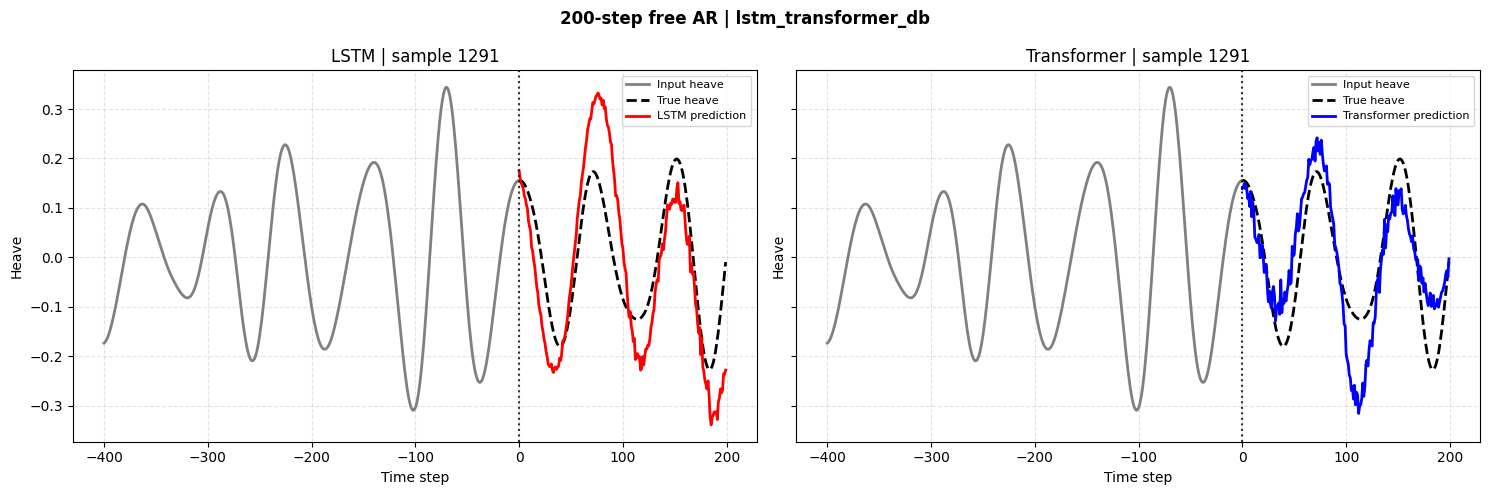

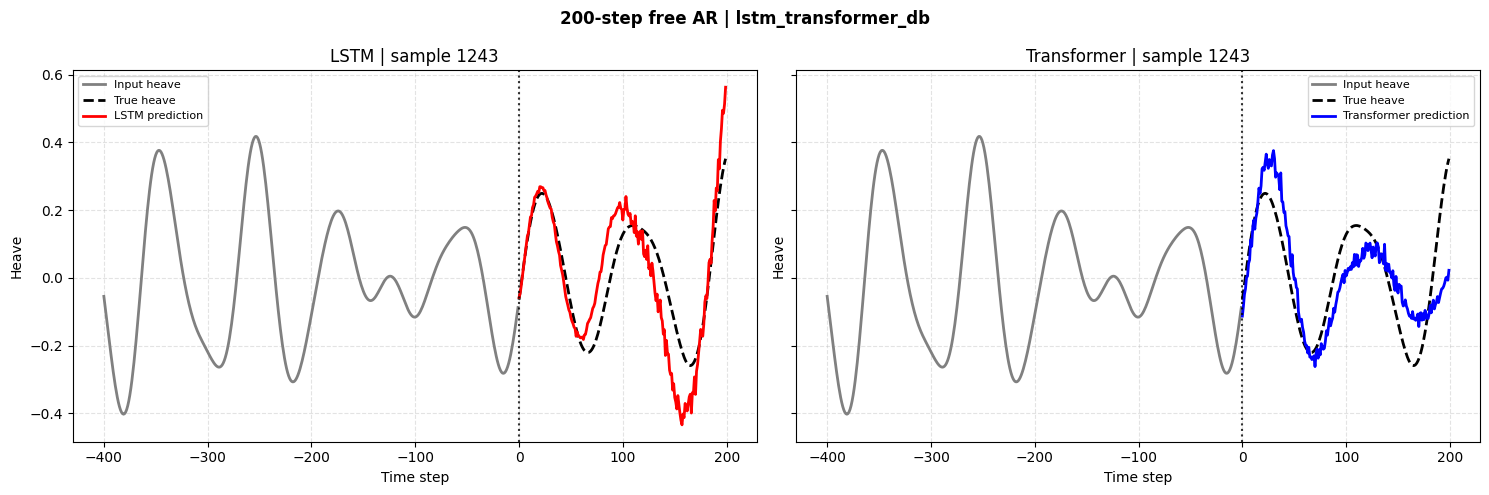

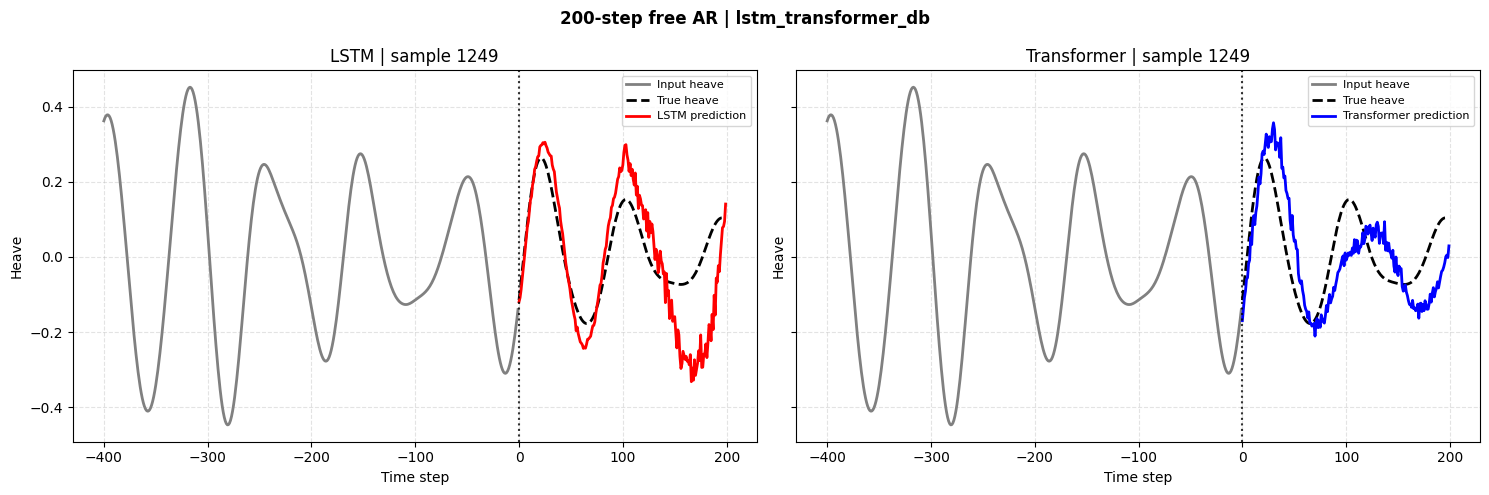

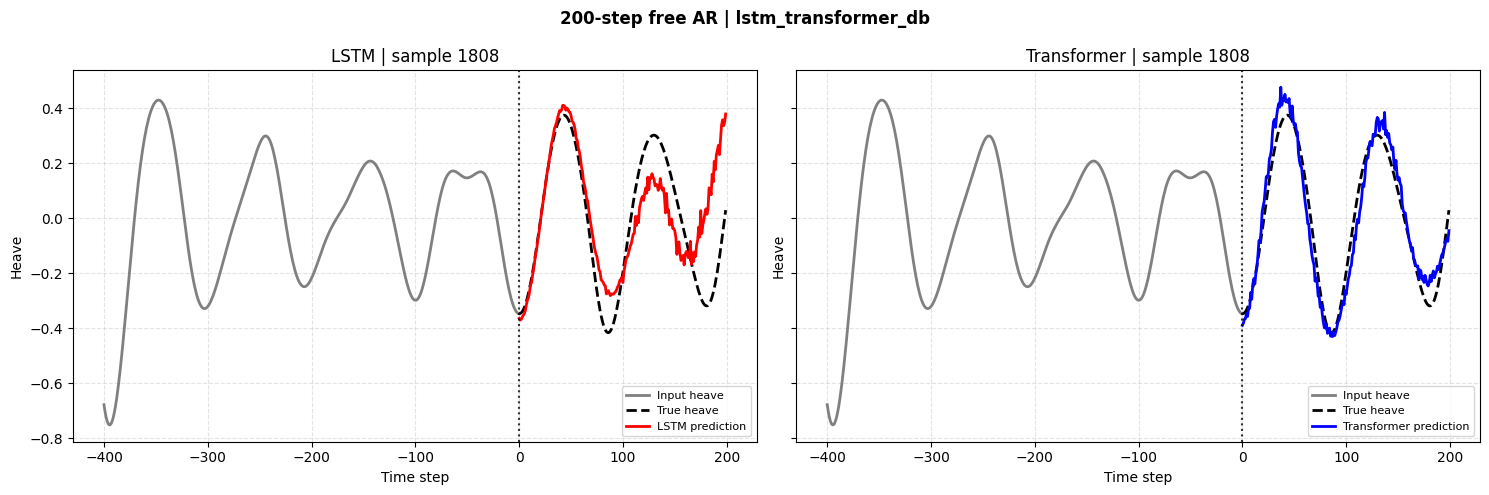

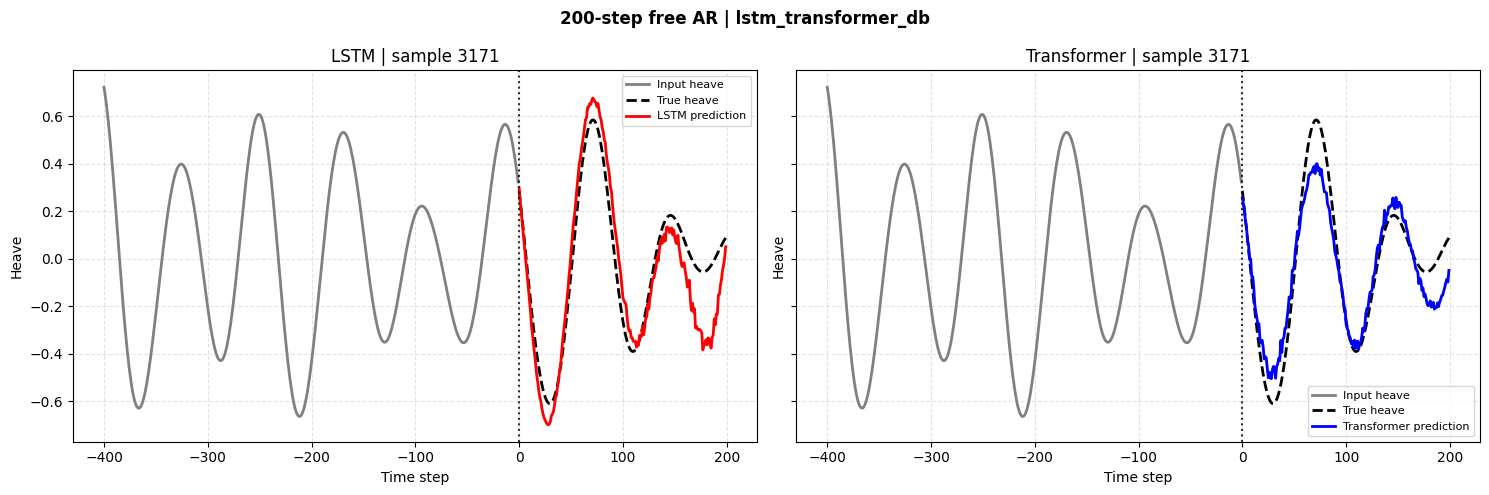

In [40]:
import numpy as np
import matplotlib.pyplot as plt

Y_LIM = None  # 예: (-3, 3). None이면 자동 범위

for sample_idx in best_idx_combined:
    xb, yb = test_dataset[int(sample_idx)]

    x_pre_scaled = model_to_pre_pca_scaled(xb.cpu().numpy())
    x_input_heave = inverse_scale_feature(
        x_pre_scaled[:, pre_pca_input_cols.index(report_col)],
        report_col,
    ).flatten()

    y_true_all = inverse_scale_targets(yb.cpu().numpy())
    y_true_heave = y_true_all[:, heave_idx]

    sample_idx = int(sample_idx)

    model_names_to_plot = [
        m for m in config["model_names"]
        if m in ar_results
    ]

    # RMSE 순위 계산에 사용한 예측값 그대로 사용
    sample_predictions = {
        model_name: np.asarray(
            ar_results[model_name]["preds_orig"][
                sample_idx, :metric_output_len
            ]
        ).reshape(-1)
        for model_name in model_names_to_plot
    }

    # 정답도 동일한 ar_results에서 가져오기
    y_true_heave = np.asarray(
        ar_results[model_names_to_plot[0]]["trues_orig"][
            sample_idx, :metric_output_len
        ]
    ).reshape(-1)

    model_names_to_plot = list(sample_predictions)
    fig, axes = plt.subplots(
        1,
        len(model_names_to_plot),
        figsize=(7.5 * len(model_names_to_plot), 5),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    x_input_axis = np.arange(-INPUT_LEN, 0)
    x_future_axis = np.arange(0, EVAL_OUTPUT_LEN)
    
    for ax, model_name in zip(axes, model_names_to_plot):
        ax.plot(x_input_axis, x_input_heave, color="gray", linewidth=2, label="Input heave")
        ax.plot(x_future_axis, y_true_heave, color="black", linestyle="--", linewidth=2, label="True heave")
        ax.plot(
            x_future_axis,
            sample_predictions[model_name],
            color=model_colors.get(model_name, "tab:gray"),
            linewidth=2,
            label=f"{model_name} prediction",
        )
        ax.axvline(0, color="black", linestyle=":", alpha=0.8)
        if Y_LIM is not None:
            ax.set_ylim(Y_LIM)
        ax.set_title(f"{model_name} | sample {sample_idx}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Heave")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(fontsize=8)

    plt.suptitle(f"200-step free AR | {config['experiment_name']}", fontweight="bold")
    plt.tight_layout()
    plt.show()


저장 완료: ./paper_figures/lstm_sample_3171_200step.png


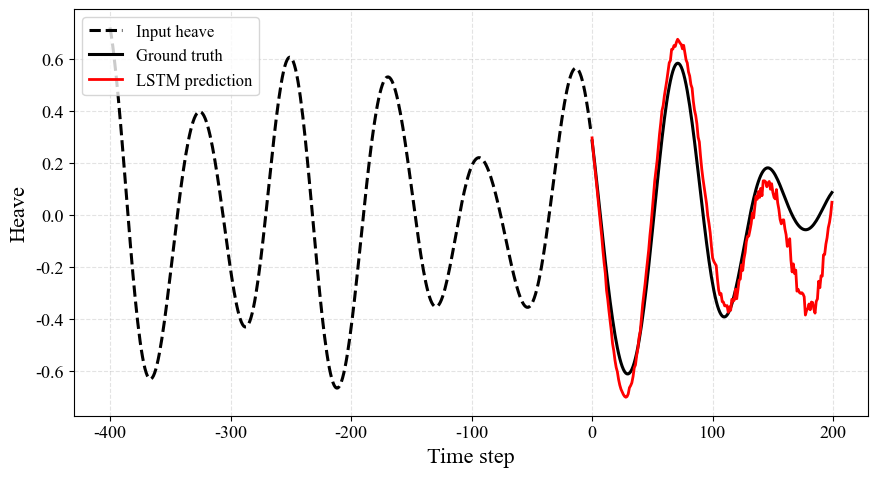

저장 완료: ./paper_figures/transformer_sample_3171_200step.png


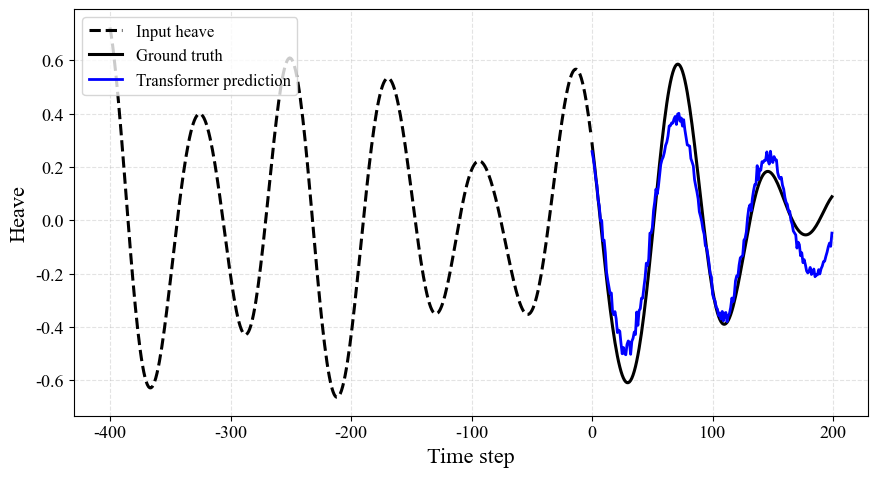

저장 완료: ./paper_figures/combined_sample_3171_200step.png


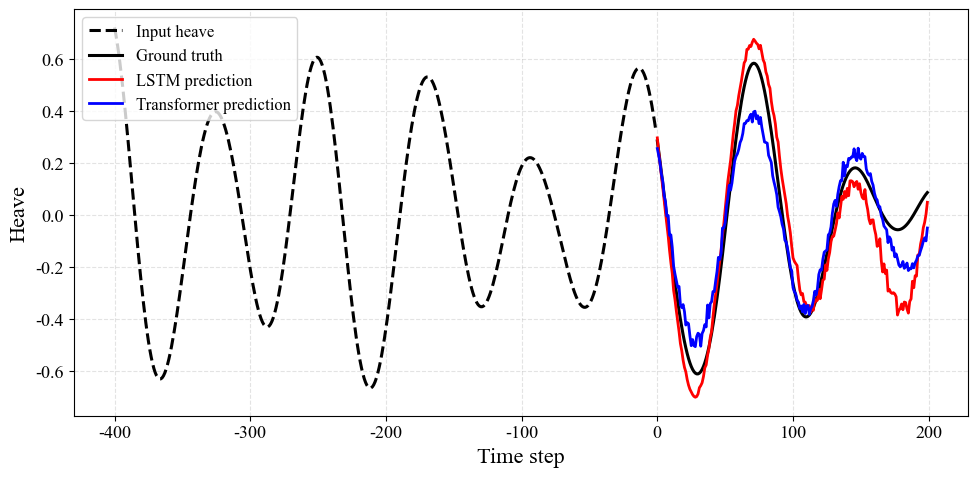

In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({
    "font.family": "Times New Roman",  # 또는 "Arial"
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.unicode_minus": False,
})

PLOT_OUTPUT_LEN = 200
SAVE_DIR = "./paper_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# config에 지정된 모델을 모두 시각화합니다.
model_names_to_plot = [model_name for model_name in config["model_names"] if model_name in results]
if not model_names_to_plot:
    raise ValueError("config[\"model_names\"]에 해당하는 학습 결과가 없습니다.")
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {
    model_name: color_cycle[index % len(color_cycle)]
    for index, model_name in enumerate(model_names_to_plot)
}

sample_idx = int(best_idx_combined[min(4, len(best_idx_combined) - 1)])
xb, yb = test_dataset[sample_idx]

# 입력 heave 복원
x_pre_scaled = model_to_pre_pca_scaled(xb.cpu().numpy())
x_input_orig = inverse_scale_feature(
    x_pre_scaled[:, pre_pca_input_cols.index(report_col)],
    report_col,
).flatten()

# 정답 heave 복원
y_true_all = inverse_scale_targets(yb.cpu().numpy())
y_true_heave = y_true_all[:, heave_idx]

xb_model = xb.unsqueeze(0).to(device)

# 각 모델 예측 저장
pred_dict = {}

for model_name in model_names_to_plot:
    result = results[model_name]

    model = result["model"]
    model.eval()

    with torch.no_grad():
        pred_scaled = autoregressive_predict_joint(
            model=model,
            xb=xb_model,
            total_output_len=PLOT_OUTPUT_LEN,
            base_len=MODEL_OUTPUT_LEN,
        ).cpu().numpy()[0]

    pred_heave = inverse_scale_targets(pred_scaled)[:, heave_idx]
    pred_dict[model_name] = pred_heave

    # -----------------------------
    # 1) 개별 그래프 저장
    # -----------------------------
    plt.figure(figsize=(9, 5))
    plt.plot(
        np.arange(-INPUT_LEN, 0),
        x_input_orig,
        color="black",
        linestyle="--",
        linewidth=2.2,
        label="Input heave"
    )
    plt.plot(
        np.arange(PLOT_OUTPUT_LEN),
        y_true_heave[:PLOT_OUTPUT_LEN],
        color="black",
        linewidth=2.2,
        label="Ground truth"
    )
    plt.plot(
        np.arange(PLOT_OUTPUT_LEN),
        pred_heave[:PLOT_OUTPUT_LEN],
        color=model_colors[model_name],
        linewidth=2.0,
        label=f"{model_name} prediction"
    )

    plt.xlabel("Time step")
    plt.ylabel("Heave")
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()

    file_name = f"{SAVE_DIR}/{model_name.lower()}_sample_{sample_idx}_200step.png"
    plt.savefig(file_name, dpi=300, bbox_inches="tight", facecolor="white")
    print("저장 완료:", file_name)
    plt.show()
    plt.close()

# -----------------------------
# 2) 합친 비교 그래프 저장
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(-INPUT_LEN, 0),
    x_input_orig,
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="Input heave"
)
plt.plot(
    np.arange(PLOT_OUTPUT_LEN),
    y_true_heave[:PLOT_OUTPUT_LEN],
    color="black",
    linewidth=2.2,
    label="Ground truth"
)

for model_name in model_names_to_plot:
    if model_name not in pred_dict:
        continue
    plt.plot(
        np.arange(PLOT_OUTPUT_LEN),
        pred_dict[model_name][:PLOT_OUTPUT_LEN],
        color=model_colors[model_name],
        linewidth=2.0,
        label=f"{model_name} prediction"
    )

plt.xlabel("Time step")
plt.ylabel("Heave")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()

combined_file_name = f"{SAVE_DIR}/combined_sample_{sample_idx}_200step.png"
plt.savefig(combined_file_name, dpi=300, bbox_inches="tight", facecolor="white")
print("저장 완료:", combined_file_name)
plt.show()
plt.close()